In [1]:
using FFTW
using GLMakie

In [2]:
function read_test(file)
    raw = split.(readlines(file),", ")
    frame = map(x -> parse(Int,x[1]),raw)
    indeces = map(x -> parse(Int,x[2]),raw)
    vals = map(x -> parse(Int,x[3]) + 1im*parse(Int,x[4]),raw)
    return frame, indeces, vals
end

read_test (generic function with 1 method)

In [ ]:
frames, fs_i, response = read_test("../testbenches/continuous.txt");

In [4]:
impulse = response[frames[1:length(response)] .== 0]
DC = response[frames[1:length(response)] .== 1]
single = response[frames[1:length(response)] .== 2]
multi = response[frames[1:length(response)] .== 3];

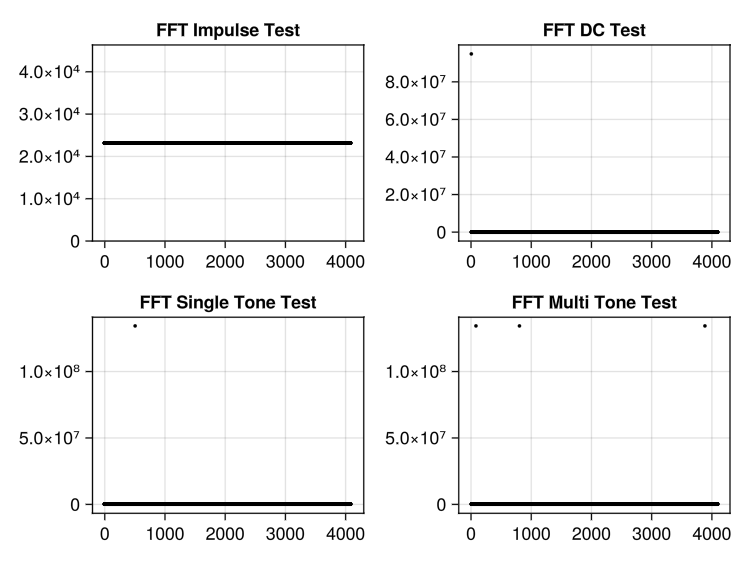

In [5]:
fig = Figure()
ax = Axis(fig[1,1],title="FFT Impulse Test")
scatter!(ax,abs.(impulse),markersize = 4,color=:black)
ax = Axis(fig[1,2],title="FFT DC Test")
scatter!(ax,abs.(DC),markersize = 4,color=:black)
ax = Axis(fig[2,1],title="FFT Single Tone Test")
scatter!(ax,abs.(single),markersize=4,color=:black)
ax = Axis(fig[2,2],title="FFT Multi Tone Test")
scatter!(ax,abs.(multi),markersize=4,color=:black)
fig

In [6]:
EVM(X,X_hat) = sqrt(sum(abs2.(X-X_hat))/(sum(abs2.(X))))

EVM (generic function with 1 method)

In [7]:
N = length(impulse)
impulse_expected = ones(Int,N)*(2^14 + 1im*2^14)
DC_expected = zeros(Complex,N)
DC_expected[1] = 2^26 + 1im*2^26
single_expected = zeros(Complex,N)
single_expected[512+1] = 2^27
multi_expected = zeros(Complex,N)
multi_expected[77+1] = 2^27
multi_expected[800+1] = 2^27
multi_expected[N-213+1] = 2^27;

In [8]:
EVM(impulse,impulse_expected)

0.0

In [9]:
EVM(DC,DC_expected)

0.00020838644580532687

In [10]:
EVM(single,single_expected)

0.00019970321431973716

In [11]:
EVM(multi,multi_expected)

0.00021933647785273504